# CIFAR10 with MLPs
Simple starter notebook to benchmark your own MLP with PyTorch on the CIFAR-10 dataset.

OBS.:

- The main code is basically done, so focus on training the models and searching for the best hyperparameters and architectures.
- You are not required to use this exact code or even the PyTorch library.
- It is recommended to use execution environments with GPU access (such as Google Colab), since larger models will take more time to train.
- Remember to document the history of your experiments and which results motivated the changes in subsequent experiments.

In [1]:
pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 14.7 MB/s eta 0:00:00


In [2]:
#@title Libs

import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics


from tqdm import tqdm

import optuna
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader, Subset
import torch.nn.functional as F
from sklearn.model_selection import train_test_split

Definimos as transformações necessárias para as imagens do dataset, convertendo elas para tensores e normalizando. Em seguida, realizamos o download e carregamento dos conjuntos de dados de treino (50.000 imagens) e teste (10.000 imagens).

In [3]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)


100%|██████████| 170M/170M [00:03<00:00, 46.0MB/s]


Para otimizar o tempo de execução da busca de hiperparâmetros com o Optuna, criamos um subconjunto estratificado de 10.000 imagens a partir do dataset de treino original. A estratificação garante que o subconjunto mantenha a mesma proporção de classes (1.000 por categoria).

In [4]:
subset_size = 10000 # subconjunto pra ir mais rápido

train_indices = list(range(len(train_dataset)))
train_labels = [train_dataset[i][1] for i in train_indices]

search_indices, _ = train_test_split(
    train_indices,
    train_size=subset_size,
    stratify=train_labels, # garante a mesma quantidade por classe
    random_state=42
)

search_dataset = Subset(train_dataset, search_indices) # só no optuna

print(f"subconjunto de busca criado com {len(search_dataset)} imagens.")
print(f"representa {len(search_dataset)//10} imagens por classe.")

subconjunto de busca criado com 10000 imagens.
representa 1000 imagens por classe.


In [5]:
class MLP(nn.Module):
    def __init__(self, input_size, num_classes, hidden_sizes, dropout_rate, activation_func):
        super(MLP, self).__init__()
        layers = []
        in_features = input_size

        for h_size in hidden_sizes:
            layers.append(nn.Linear(in_features, h_size))
            layers.append(activation_func)
            layers.append(nn.Dropout(dropout_rate))
            in_features = h_size

        layers.append(nn.Linear(in_features, num_classes))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

In [6]:
def get_scores(targets, predictions):
    return {
        "accuracy": metrics.accuracy_score(targets, predictions),
        "balanced_accuracy": metrics.balanced_accuracy_score(targets, predictions),
        "precision": metrics.precision_score(targets, predictions, average="weighted"),
        "recall": metrics.recall_score(targets, predictions, average="weighted"),
        "f1_score": metrics.f1_score(targets, predictions, average="weighted")
    }

### Espaço de Busca e Arquiteturas
Para investigar o impacto da arquitetura da rede, definimos o arch_dict, que oferece desde modelos clássicos até variações extremas:

- Original_Losango: A arquitetura base sugerida no projeto.

- Skinny Deep: Uma rede profunda (5 camadas) e estreita para testar a propagação de gradientes.

- Rasa (Wide): Uma única camada massiva de 4096 neurônios para testar o poder da largura vs. profundidade.

- Enorme/Grande: Modelos com alta capacidade de processamento para datasets complexos.

Além da arquitetura, o Optuna varia dinamicamente a Taxa de Aprendizado (lr), o Dropout (regularização), o Weight Decay (L2) e o Batch Size. Também incluímos ativações modernas como LeakyReLU para evitar o problema de neurônios mortos.

### Validação Cruzada (K-Fold) e Estabilidade
Para garantir que a performance não seja fruto de uma divisão sortuda dos dados, implementamos o K-Fold Cross-Validation (k=3). O subconjunto de busca (search_dataset) é dividido em 3 partes: o modelo treina em duas e valida na terceira, repetindo o processo até que todas as partes tenham sido usadas para validação.

### Ciclo de Treinamento e Eficiência
Cada fold executa um treino curto de 5 épocas. Embora pareça pouco, este "orçamento" de tempo é suficiente para o Optuna identificar tendências de convergência e descartar configurações ineficientes rapidamente.

In [7]:
def objective(trial):
    arch_dict = {
            "Original_Losango": (64, 128, 64),
            "Funil_Largo": (256, 128, 64),
            "Grande": (1024, 512, 256, 128),
            "Enorme": (2048, 1024, 512, 256, 128),
            "Via": (2048, 256)
        }

    arch_name = trial.suggest_categorical("arch_name", list(arch_dict.keys()))
    hidden_sizes = arch_dict[arch_name]

    dropout_rate = trial.suggest_float("dropout", 0.2, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-4, 1e-2, log=True)

    activation_name = trial.suggest_categorical("activation", ["ReLU", "Tanh", "LeakyReLU"])
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "SGD"])
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])

    activations = {
        "ReLU": nn.ReLU(),
        "Tanh": nn.Tanh(),
        "LeakyReLU": nn.LeakyReLU()
    }

    print(f"Iniciando Trial #{trial.number}")
    print(f"Arquitetura: {arch_name} {hidden_sizes}")
    print(f"Otimizador: {optimizer_name} | LR: {lr:.5f} | Dropout: {dropout_rate:.2f}")

    k_folds = 3
    kfold = KFold(n_splits=k_folds, shuffle=True)
    fold_accuracies = []

    for fold, (train_ids, val_ids) in enumerate(kfold.split(search_dataset)):
        train_sub = Subset(search_dataset, train_ids)
        val_sub = Subset(search_dataset, val_ids)
        t_loader = DataLoader(train_sub, batch_size=batch_size, shuffle=True)
        v_loader = DataLoader(val_sub, batch_size=batch_size, shuffle=False)

        model = MLP(3072, 10, hidden_sizes, dropout_rate, activations[activation_name]).cuda()
        optimizer = getattr(torch.optim, optimizer_name)(model.parameters(), lr=lr, weight_decay=weight_decay)

        # loop de treino curto
        for epoch in range(5):
            model.train()
            for images, labels in t_loader:
                images = images.view(-1, 3072).cuda()
                labels = labels.cuda()

                optimizer.zero_grad()
                outputs = model(images)

                loss = nn.CrossEntropyLoss()(outputs, labels)
                loss.backward()
                optimizer.step()

        model.eval()
        correct = 0
        with torch.no_grad():
            for images, labels in v_loader:
                images = images.view(-1, 3072).cuda()
                outputs = model(images)
                pred = outputs.argmax(dim=1)
                correct += pred.eq(labels.cuda()).sum().item()

        acc = correct / len(val_ids)
        fold_accuracies.append(acc)
        print(f"  > Fold {fold+1}/{k_folds} finalizado. Acurácia: {acc:.4f}")

    mean_accuracy = np.mean(fold_accuracies)

    print(f"RESULTADO TRIAL #{trial.number}: Acurácia Média (CV) = {mean_accuracy:.4f}")

    return mean_accuracy

In [8]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def final_evaluation(best_model, test_loader):
    best_model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.view(-1, 3072).cuda()
            outputs = best_model(images)
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.numpy())

    # acurácia por classe e métricas totais
    print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

    # Matriz de Confusão
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
    plt.ylabel('Real')
    plt.xlabel('Previsto')
    plt.show()

In [9]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

print(f"Melhor Acurácia de Validação: {study.best_value:.4f}")
print(f"Melhores Parâmetros: {study.best_params}")

[I 2026-03-28 21:06:31,576] A new study created in memory with name: no-name-08d83294-4e37-4c3c-8c49-82eaf8ebc105


Iniciando Trial #0
Arquitetura: Original_Losango (64, 128, 64)
Otimizador: SGD | LR: 0.00281 | Dropout: 0.41
  > Fold 1/3 finalizado. Acurácia: 0.2187
  > Fold 2/3 finalizado. Acurácia: 0.2325


[I 2026-03-28 21:07:13,612] Trial 0 finished with value: 0.22390052442556793 and parameters: {'arch_name': 'Original_Losango', 'dropout': 0.41485149677355343, 'lr': 0.0028143219221454193, 'weight_decay': 0.00014208849553033008, 'activation': 'LeakyReLU', 'optimizer': 'SGD', 'batch_size': 16}. Best is trial 0 with value: 0.22390052442556793.


  > Fold 3/3 finalizado. Acurácia: 0.2205
RESULTADO TRIAL #0: Acurácia Média (CV) = 0.2239
Iniciando Trial #1
Arquitetura: Grande (1024, 512, 256, 128)
Otimizador: SGD | LR: 0.00221 | Dropout: 0.42
  > Fold 1/3 finalizado. Acurácia: 0.2304
  > Fold 2/3 finalizado. Acurácia: 0.2490


[I 2026-03-28 21:07:43,126] Trial 1 finished with value: 0.23720068467554614 and parameters: {'arch_name': 'Grande', 'dropout': 0.4235958284559489, 'lr': 0.002213426930473801, 'weight_decay': 0.0003174687169244029, 'activation': 'Tanh', 'optimizer': 'SGD', 'batch_size': 64}. Best is trial 1 with value: 0.23720068467554614.


...

  > Fold 3/3 finalizado. Acurácia: 0.3783
RESULTADO TRIAL #97: Acurácia Média (CV) = 0.3749
Iniciando Trial #98
Arquitetura: Via (2048, 256)
Otimizador: Adam | LR: 0.00014 | Dropout: 0.28
  > Fold 1/3 finalizado. Acurácia: 0.4199
  > Fold 2/3 finalizado. Acurácia: 0.4218


[I 2026-03-28 21:56:18,737] Trial 98 finished with value: 0.4249004984481652 and parameters: {'arch_name': 'Via', 'dropout': 0.28059537811679436, 'lr': 0.00014233444766414386, 'weight_decay': 0.0024386209197384, 'activation': 'LeakyReLU', 'optimizer': 'Adam', 'batch_size': 64}. Best is trial 81 with value: 0.435699478766113.


  > Fold 3/3 finalizado. Acurácia: 0.4329
RESULTADO TRIAL #98: Acurácia Média (CV) = 0.4249
Iniciando Trial #99
Arquitetura: Via (2048, 256)
Otimizador: SGD | LR: 0.00023 | Dropout: 0.31
  > Fold 1/3 finalizado. Acurácia: 0.1605
  > Fold 2/3 finalizado. Acurácia: 0.1095


[I 2026-03-28 21:56:45,942] Trial 99 finished with value: 0.1337973329426524 and parameters: {'arch_name': 'Via', 'dropout': 0.3073008400322049, 'lr': 0.00023482095789425773, 'weight_decay': 0.0007907006955394271, 'activation': 'LeakyReLU', 'optimizer': 'SGD', 'batch_size': 64}. Best is trial 81 with value: 0.435699478766113.


  > Fold 3/3 finalizado. Acurácia: 0.1314
RESULTADO TRIAL #99: Acurácia Média (CV) = 0.1338
Melhor Acurácia de Validação: 0.4357
Melhores Parâmetros: {'arch_name': 'Via', 'dropout': 0.2925547899909114, 'lr': 0.00014888602844586717, 'weight_decay': 0.0003493070307834849, 'activation': 'LeakyReLU', 'optimizer': 'Adam', 'batch_size': 128}



Treinando o modelo final
Parâmetros Otimizados: {'arch_name': 'Via', 'dropout': 0.2925547899909114, 'lr': 0.00014888602844586717, 'weight_decay': 0.0003493070307834849, 'activation': 'LeakyReLU', 'optimizer': 'Adam', 'batch_size': 128}


Época 1 finalizada. Loss Média: 1.7101


Época 2 finalizada. Loss Média: 1.5162


Época 3 finalizada. Loss Média: 1.4276


Época 4 finalizada. Loss Média: 1.3666


...

Época 96 finalizada. Loss Média: 0.3153


Época 97 finalizada. Loss Média: 0.3094


Época 98 finalizada. Loss Média: 0.3062


Época 99 finalizada. Loss Média: 0.3129


Época 100 finalizada. Loss Média: 0.2986
              precision    recall  f1-score   support

    airplane       0.63      0.67      0.65      1000
  automobile       0.66      0.71      0.68      1000
        bird       0.43      0.49      0.46      1000
         cat       0.37      0.46      0.41      1000
        deer       0.53      0.43      0.47      1000
         dog       0.48      0.40      0.44      1000
        frog       0.58      0.67      0.62      1000
       horse       0.67      0.64      0.66      1000
        ship       0.74      0.67      0.70      1000
       truck       0.69      0.57      0.63      1000

    accuracy                           0.57     10000
   macro avg       0.58      0.57      0.57     10000
weighted avg       0.58      0.57      0.57     10000



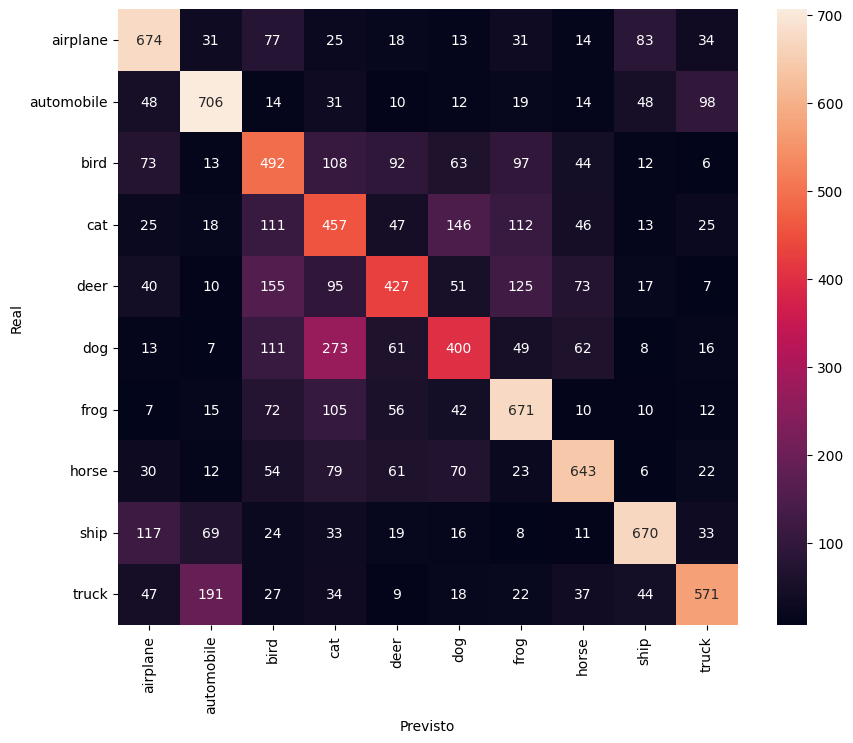

In [10]:
df_results = study.trials_dataframe() #000000000000000000000000
df_results.to_csv("experimentos_mlp_optuna.csv", index=False)
best_params = study.best_params
activations = {"ReLU": nn.ReLU(), "Tanh": nn.Tanh(), "LeakyReLU": nn.LeakyReLU()}

arch_dict = {
        "Original_Losango": (64, 128, 64),
        "Funil_Largo": (256, 128, 64),
        "Grande": (1024, 512, 256, 128),
        "Enorme": (2048, 1024, 512, 256, 128),
        "Via": (2048, 256)
    }
best_arch_name = best_params["arch_name"]
best_hidden_sizes = arch_dict[best_arch_name]

print(f"\nTreinando o modelo final")
print(f"Parâmetros Otimizados: {best_params}")

# arquitetura vencedora
best_model = MLP(
    input_size=3072,
    num_classes=10,
    hidden_sizes=best_hidden_sizes,
    dropout_rate=study.best_params["dropout"],
    activation_func=activations[study.best_params["activation"]]
).cuda() # gpu

optimizer = getattr(torch.optim, best_params["optimizer"])(best_model.parameters(), lr=best_params["lr"], weight_decay=best_params.get("weight_decay", 0.0))
full_train_loader = DataLoader(train_dataset, batch_size=best_params["batch_size"], shuffle=True)

# treino final
best_loss = float('inf')
patience = 5
patience_counter = 0
max_epochs = 100
best_model_path = 'melhor_modelo_mlp_final.pth'

for epoch in range(max_epochs):
    best_model.train()
    epoch_loss = 0.0

    for images, labels in tqdm(full_train_loader, desc=f"Epoch {epoch+1}/{max_epochs}", leave=False):
        images = images.view(-1, 3072).cuda()
        labels = labels.cuda()

        optimizer.zero_grad()
        outputs = best_model(images)

        loss = nn.CrossEntropyLoss()(outputs, labels)

        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / len(full_train_loader)
    print(f"Época {epoch+1} finalizada. Loss Média: {avg_epoch_loss:.4f}")

    if avg_epoch_loss < best_loss:
        best_loss = avg_epoch_loss
        patience_counter = 0
        torch.save(best_model.state_dict(), best_model_path)
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n Early Stopping ativado na época {epoch+1}.")
            break

# avaliação final
best_model.load_state_dict(torch.load(best_model_path))
final_evaluation(best_model, DataLoader(test_dataset, batch_size=64, shuffle=False))

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# a
best_model.load_state_dict(torch.load('melhor_modelo_mlp_final.pth'))
best_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in DataLoader(test_dataset, batch_size=64, shuffle=False):
        images = images.view(-1, 3072).cuda()
        outputs = best_model(images)
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())

acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='weighted')
rec = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

print("MÉTRICAS DETALHADAS (ALTA PRECISÃO)")
print("="*40)
print(f"Acurácia:  {acc:.6f}")
print(f"Precisão:  {prec:.6f} (weighted)")
print(f"Recall:    {rec:.6f} (weighted)")
print(f"F1-Score:  {f1:.6f} (weighted)")

MÉTRICAS DETALHADAS (ALTA PRECISÃO)
Acurácia:  0.571100
Precisão:  0.578488 (weighted)
Recall:    0.571100 (weighted)
F1-Score:  0.571888 (weighted)


In [12]:
import optuna.visualization as vis

vis.plot_param_importances(study).show()

vis.plot_optimization_history(study).show()

vis.plot_parallel_coordinate(study).show()